# Sleep Health & Lifestyle Analysis

**Part A** — Kaggle *Sleep Health and Lifestyle* dataset: EDA, preprocessing, RF & XGBoost regressors  
**Part B** — Bridge with EEG sleep-quality scores from `1.ipynb` (`eeg_sleep_quality.csv`)

---

In [1]:
# ── Imports ──────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             explained_variance_score)
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 120,
})
sns.set_style('whitegrid')
print("✅ Imports loaded")

✅ Imports loaded


## Part A — Kaggle Sleep Health & Lifestyle Dataset

In [2]:
# ── Load the Kaggle dataset ──────────────────────────────────
# Source: https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset
CSV_PATH = 'Sleep_health_and_lifestyle_dataset.csv'

# Try common locations
for candidate in [CSV_PATH,
                  os.path.join('data', CSV_PATH),
                  r"C:\Users\manne\Downloads\archive (2)\Sleep_health_and_lifestyle_dataset.csv"]:
    if os.path.exists(candidate):
        CSV_PATH = candidate
        break

df = pd.read_csv(CSV_PATH)
print(f"Loaded {CSV_PATH}  —  {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Loaded C:\Users\manne\Downloads\archive (2)\Sleep_health_and_lifestyle_dataset.csv  —  374 rows × 13 columns


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [3]:
# ── Basic EDA ────────────────────────────────────────────────
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values ✅")
print("\nDescriptive statistics:")
df.describe().round(2)

Shape: (374, 13)

Data types:
Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

Missing values:
Sleep Disorder    219
dtype: int64

Descriptive statistics:


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.00,374.00,374.00,374.00,374.00,374.00,374.00,374.00
mean,187.50,42.18,7.13,7.31,59.17,5.39,70.17,6816.84
std,108.11,8.67,0.80,1.20,20.83,1.77,4.14,1617.92
min,1.00,27.00,5.80,4.00,30.00,3.00,65.00,3000.00
25%,94.25,35.25,6.40,6.00,45.00,4.00,68.00,5600.00
50%,187.50,43.00,7.20,7.00,60.00,5.00,70.00,7000.00
75%,280.75,50.00,7.80,8.00,75.00,7.00,72.00,8000.00
max,374.00,59.00,8.50,9.00,90.00,8.00,86.00,10000.00


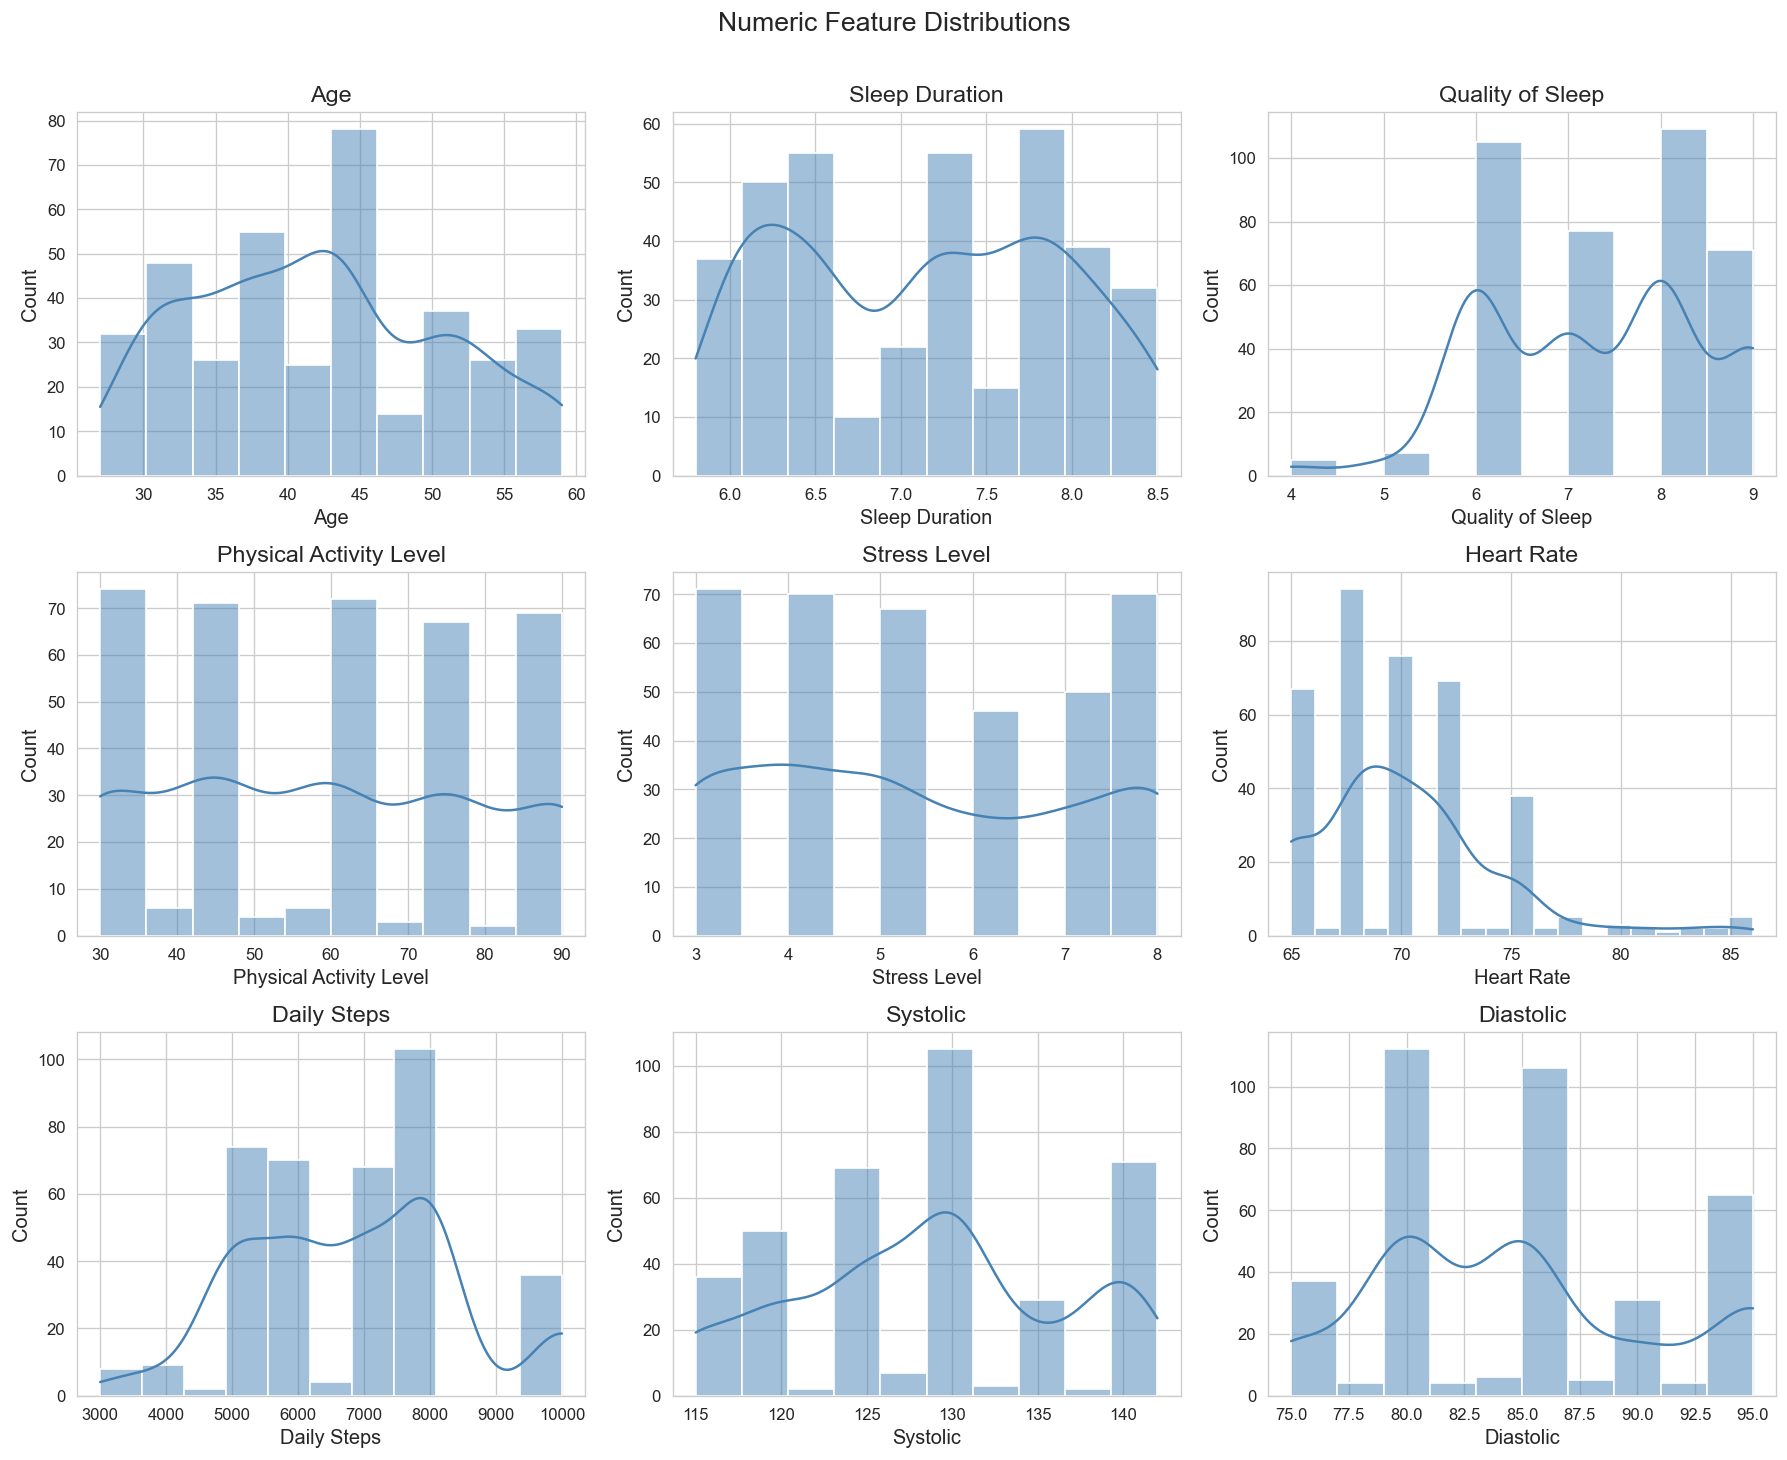

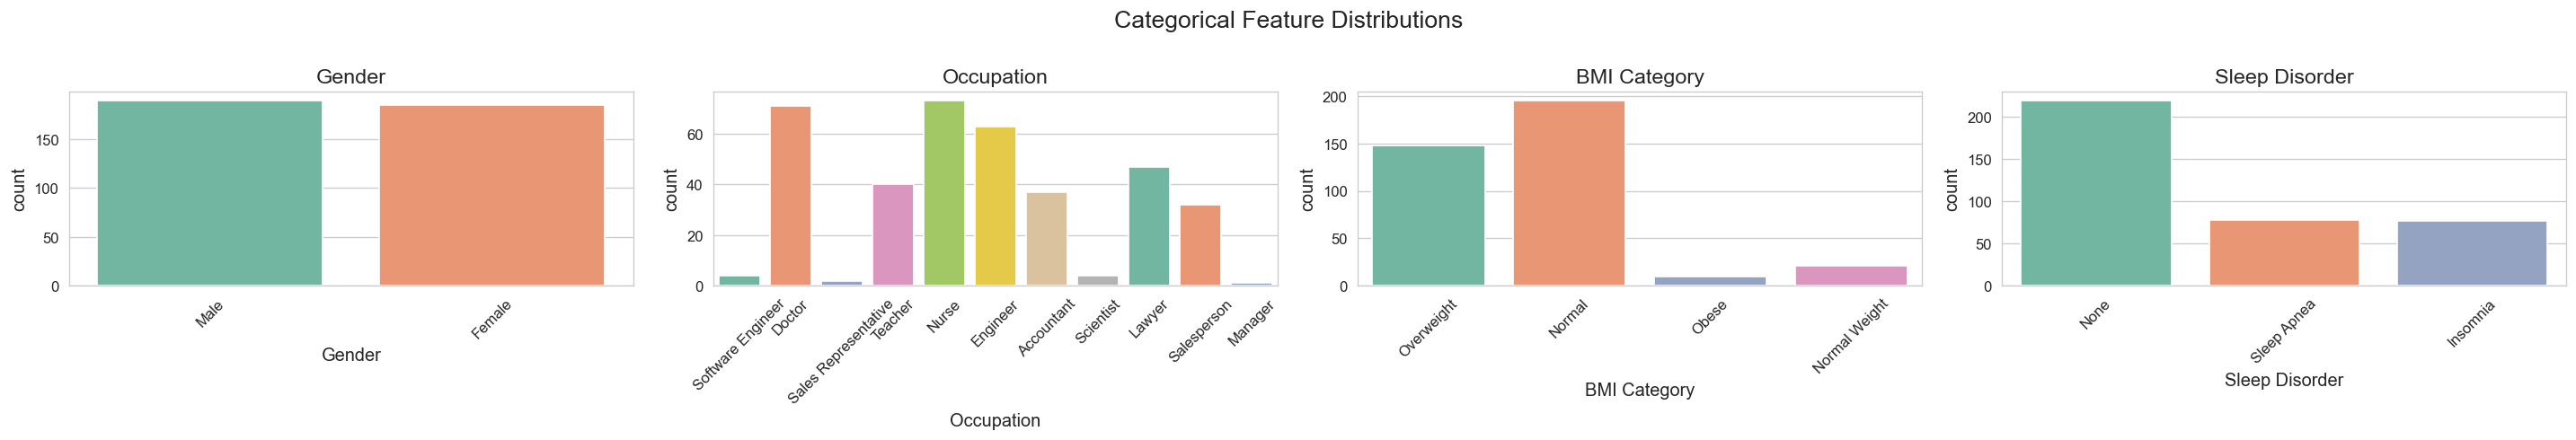

In [4]:
# ── Distribution Visualisations ──────────────────────────────
# Fill NaN in Sleep Disorder
if 'Sleep Disorder' in df.columns:
    df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

# Split Blood Pressure into Systolic / Diastolic
if 'Blood Pressure' in df.columns:
    df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
    df.drop(columns=['Blood Pressure'], inplace=True)

# Numeric distributions
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Person ID' in num_cols:
    num_cols.remove('Person ID')

n = len(num_cols)
cols_per_row = 3
rows = int(np.ceil(n / cols_per_row))
fig, axes = plt.subplots(rows, cols_per_row, figsize=(5 * cols_per_row, 4 * rows))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.suptitle('Numeric Feature Distributions', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# Categorical distributions
cat_cols = df.select_dtypes(include='object').columns.tolist()
if cat_cols:
    fig, axes = plt.subplots(1, len(cat_cols), figsize=(6 * len(cat_cols), 4))
    if len(cat_cols) == 1:
        axes = [axes]
    for i, col in enumerate(cat_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='Set2')
        axes[i].set_title(col)
        axes[i].tick_params(axis='x', rotation=45)
    plt.suptitle('Categorical Feature Distributions', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

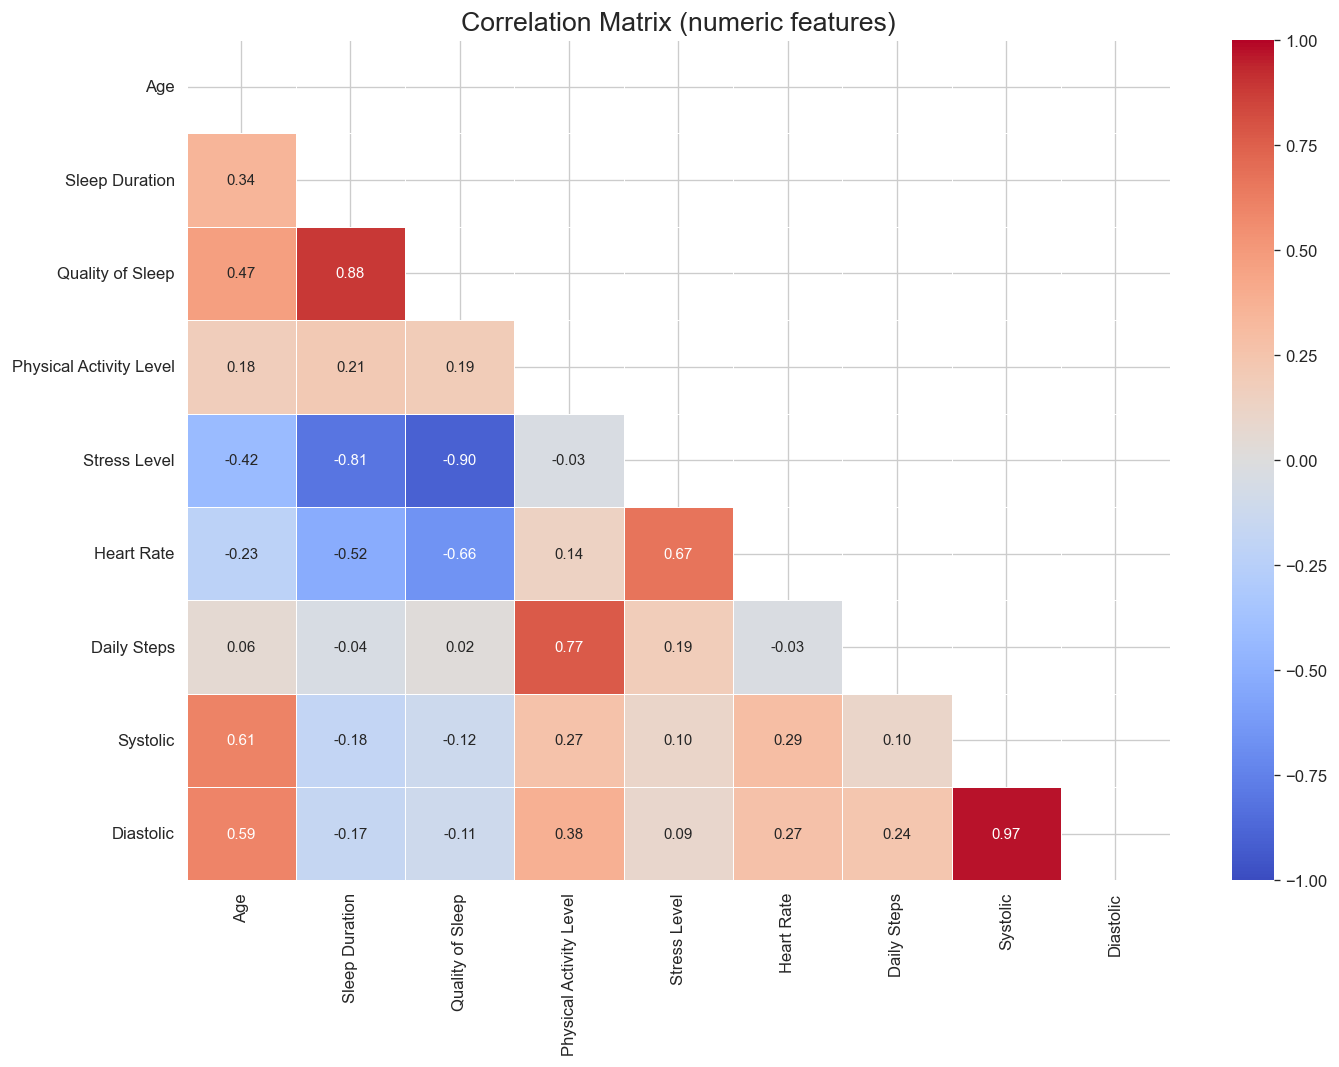


Correlations with Sleep Duration:
Sleep Duration             1.000
Quality of Sleep           0.883
Age                        0.345
Physical Activity Level    0.212
Daily Steps               -0.040
Diastolic                 -0.167
Systolic                  -0.180
Heart Rate                -0.516
Stress Level              -0.811
Name: Sleep Duration, dtype: float64


In [5]:
# ── Correlation Heatmap ──────────────────────────────────────
plt.figure(figsize=(12, 9))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 9}, vmin=-1, vmax=1)
plt.title('Correlation Matrix (numeric features)', fontsize=16)
plt.tight_layout()
plt.savefig('lifestyle_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with Sleep Duration
if 'Sleep Duration' in corr.columns:
    print("\nCorrelations with Sleep Duration:")
    print(corr['Sleep Duration'].sort_values(ascending=False).round(3))

In [6]:
# ── Preprocessing ────────────────────────────────────────────
df_model = df.copy()

# Drop ID
if 'Person ID' in df_model.columns:
    df_model.drop(columns=['Person ID'], inplace=True)

# Encode categoricals
label_encoders = {}
for col in df_model.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded '{col}': {list(le.classes_)}")

# Target = Quality of Sleep (regression target)
TARGET = 'Quality of Sleep'
if TARGET not in df_model.columns:
    # fallback
    sleep_cols = [c for c in df_model.columns if 'quality' in c.lower() or 'sleep' in c.lower()]
    TARGET = sleep_cols[0] if sleep_cols else df_model.columns[-1]

print(f"\nTarget: {TARGET}")

feature_cols = [c for c in df_model.columns if c != TARGET]
X = df_model[feature_cols]
y = df_model[TARGET]

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_sc = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

Encoded 'Gender': ['Female', 'Male']
Encoded 'Occupation': ['Accountant', 'Doctor', 'Engineer', 'Lawyer', 'Manager', 'Nurse', 'Sales Representative', 'Salesperson', 'Scientist', 'Software Engineer', 'Teacher']
Encoded 'BMI Category': ['Normal', 'Normal Weight', 'Obese', 'Overweight']
Encoded 'Sleep Disorder': ['Insomnia', 'None', 'Sleep Apnea']

Target: Quality of Sleep
Train: 299  |  Test: 75


In [7]:
# ── Train Random Forest & XGBoost ────────────────────────────
models = {}

# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=3,
                           random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)
rf_pred = rf.predict(X_test_sc)
rf_cv = cross_val_score(rf, X_train_sc, y_train, cv=5, scoring='r2')
models['Random Forest'] = {
    'model': rf, 'pred': rf_pred,
    'r2': r2_score(y_test, rf_pred),
    'mae': mean_absolute_error(y_test, rf_pred),
    'rmse': np.sqrt(mean_squared_error(y_test, rf_pred)),
    'cv_r2_mean': rf_cv.mean(), 'cv_r2_std': rf_cv.std(),
}

# --- XGBoost ---
xgb = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8,
                    random_state=42, verbosity=0)
xgb.fit(X_train_sc, y_train, eval_set=[(X_test_sc, y_test)], verbose=False)
xgb_pred = xgb.predict(X_test_sc)
xgb_cv = cross_val_score(xgb, X_train_sc, y_train, cv=5, scoring='r2')
models['XGBoost'] = {
    'model': xgb, 'pred': xgb_pred,
    'r2': r2_score(y_test, xgb_pred),
    'mae': mean_absolute_error(y_test, xgb_pred),
    'rmse': np.sqrt(mean_squared_error(y_test, xgb_pred)),
    'cv_r2_mean': xgb_cv.mean(), 'cv_r2_std': xgb_cv.std(),
}

# Comparison table
comp = pd.DataFrame({name: {k: v for k, v in m.items() if k != 'model' and k != 'pred'}
                      for name, m in models.items()}).T
print(comp.round(4).to_string())
print(f"\n🏆 Best: {comp['r2'].idxmax()}  (R²={comp['r2'].max():.4f})")

                   r2     mae    rmse  cv_r2_mean  cv_r2_std
Random Forest  0.9815  0.0568  0.1669      0.9645     0.0078
XGBoost        0.9956  0.0183  0.0817      0.9702     0.0118

🏆 Best: XGBoost  (R²=0.9956)


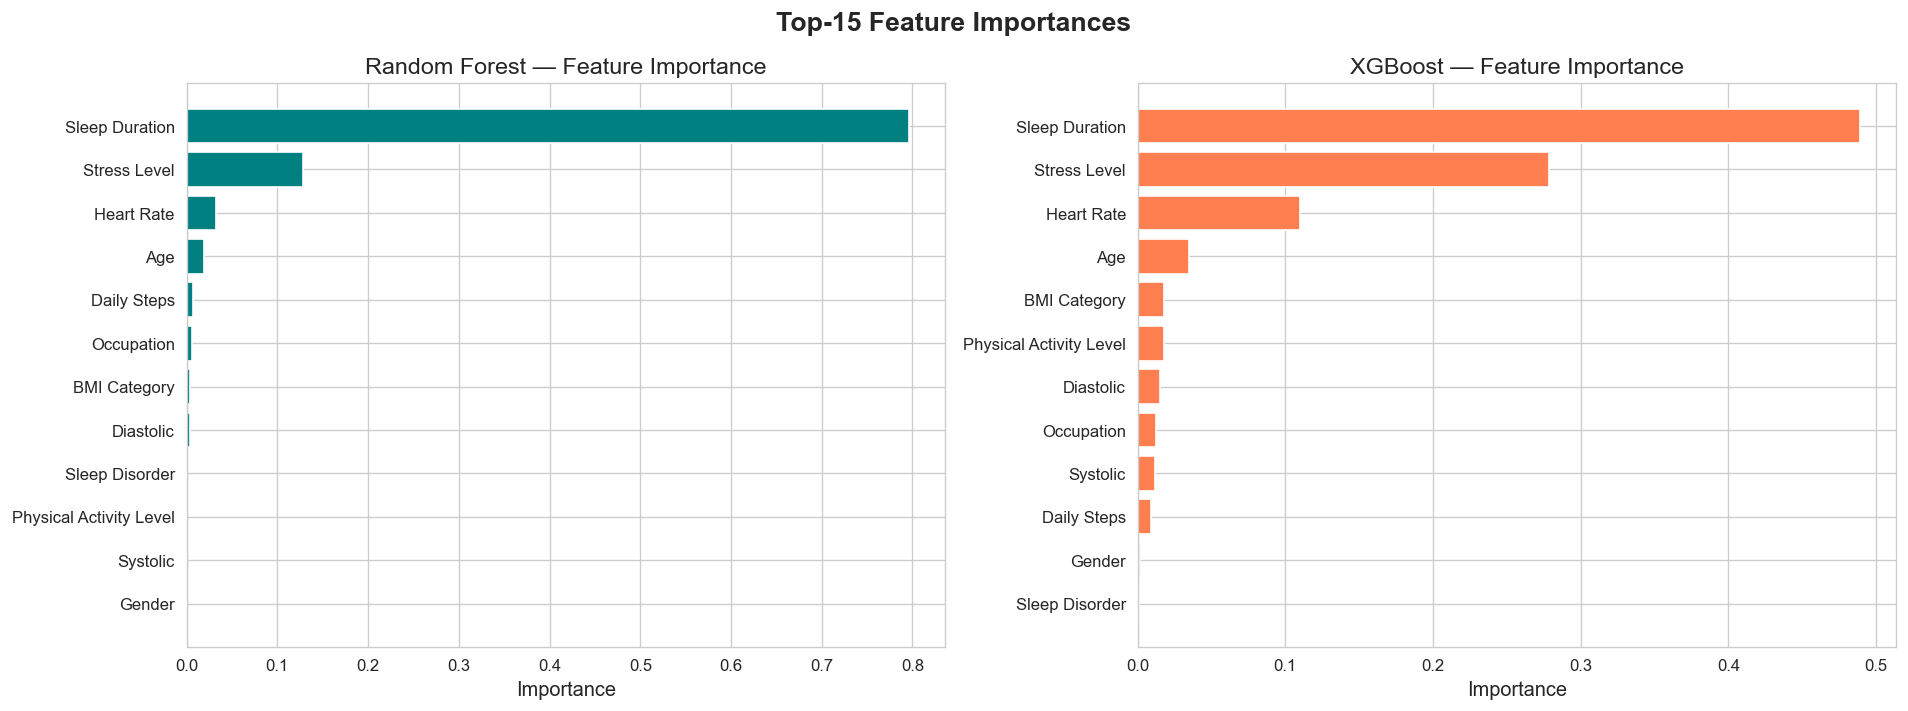

In [8]:
# ── Feature Importance (both models) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, m) in zip(axes, models.items()):
    imp = m['model'].feature_importances_
    idx = np.argsort(imp)[-15:]  # top 15
    ax.barh(np.array(feature_cols)[idx], imp[idx], color='teal' if name == 'Random Forest' else 'coral')
    ax.set_xlabel('Importance')
    ax.set_title(f'{name} — Feature Importance')

plt.suptitle('Top-15 Feature Importances', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('lifestyle_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

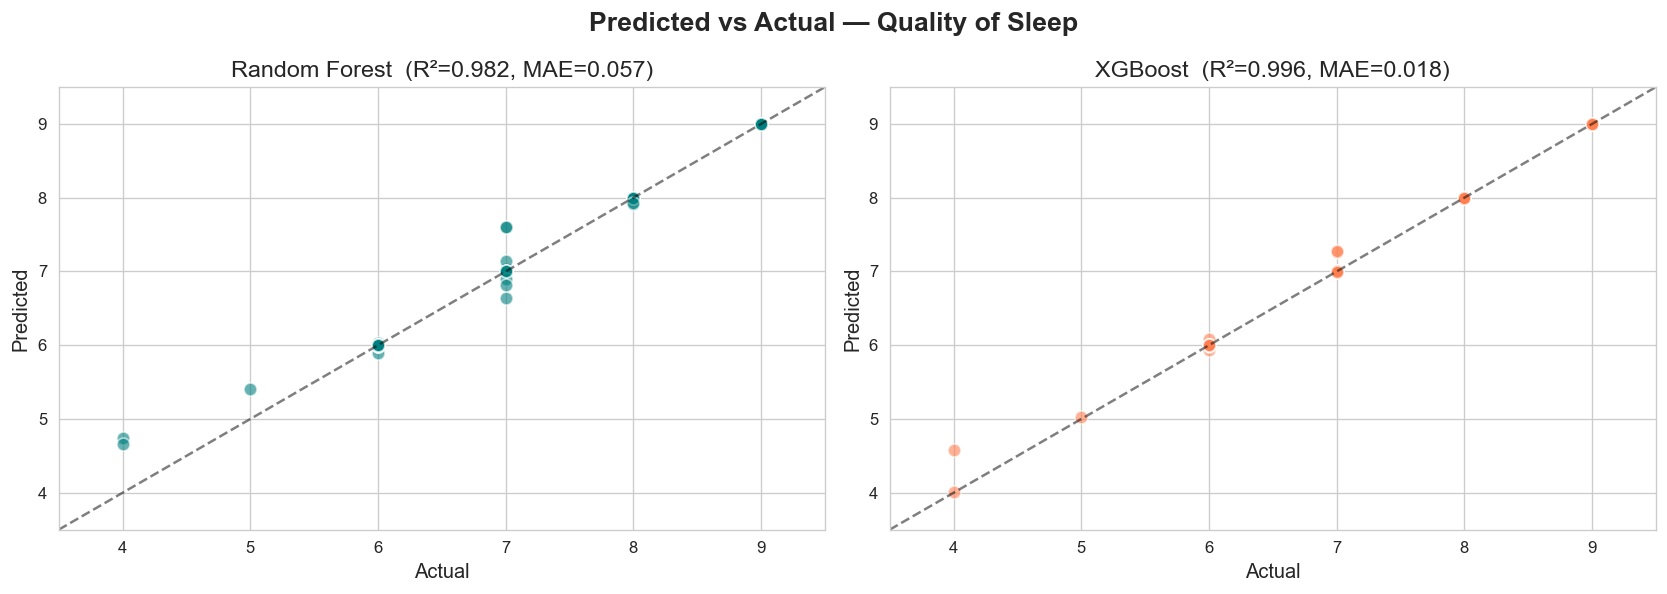

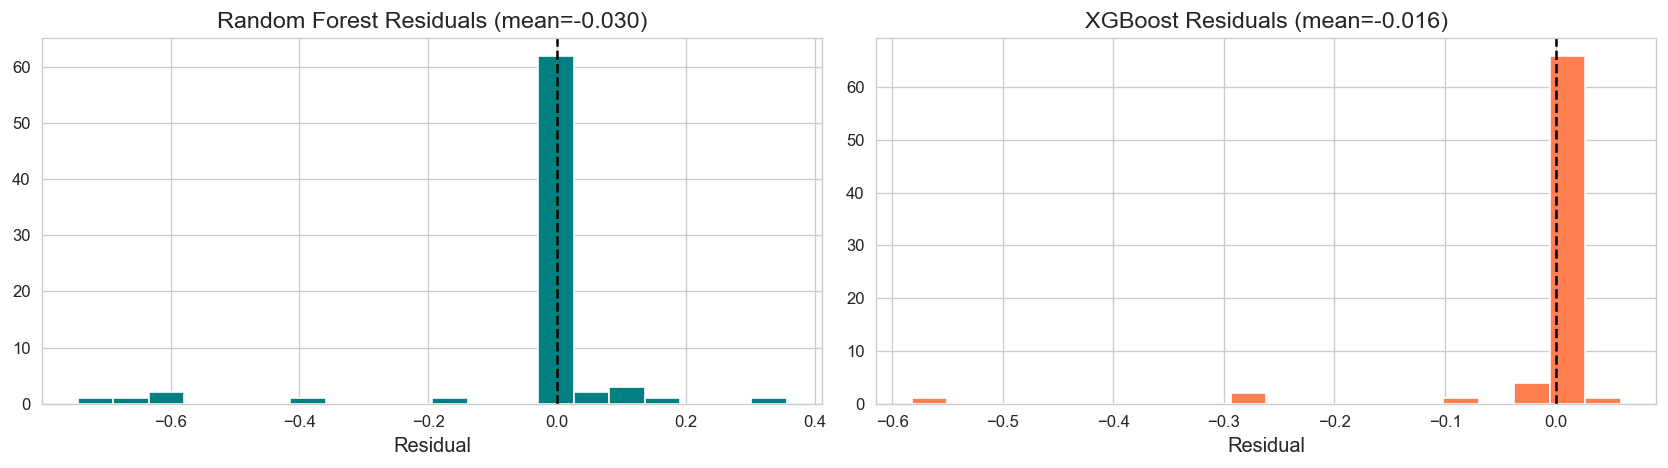

In [9]:
# ── Predictions vs Actual ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, m) in zip(axes, models.items()):
    ax.scatter(y_test, m['pred'], alpha=0.6, edgecolor='white', s=60,
               color='teal' if name == 'Random Forest' else 'coral')
    lims = [min(y_test.min(), m['pred'].min()) - 0.5,
            max(y_test.max(), m['pred'].max()) + 0.5]
    ax.plot(lims, lims, '--k', alpha=0.5)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f"{name}  (R²={m['r2']:.3f}, MAE={m['mae']:.3f})")

plt.suptitle(f'Predicted vs Actual — {TARGET}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('lifestyle_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

# Residual distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (name, m) in zip(axes, models.items()):
    residuals = y_test.values - m['pred']
    ax.hist(residuals, bins=20, edgecolor='white',
            color='teal' if name == 'Random Forest' else 'coral')
    ax.axvline(0, color='black', ls='--')
    ax.set_xlabel('Residual')
    ax.set_title(f'{name} Residuals (mean={residuals.mean():.3f})')
plt.tight_layout()
plt.show()

---

## Part B — EEG Bridge Analysis

Load `eeg_sleep_quality.csv` produced by `1.ipynb` (Phase 8).  
This bridges **objective EEG-based sleep quality** with the **survey-based lifestyle** dataset.

In [10]:
# ── Load the EEG bridge CSV ──────────────────────────────────
EEG_BRIDGE = 'eeg_sleep_quality.csv'

if not os.path.exists(EEG_BRIDGE):
    print(f"⚠️  {EEG_BRIDGE} not found. Run 1.ipynb (Phase 8) first!")
    print("    Skipping Part B.")
    eeg_available = False
else:
    df_eeg = pd.read_csv(EEG_BRIDGE)
    print(f"✅ Loaded {EEG_BRIDGE}  —  {df_eeg.shape[0]} subjects")
    print(df_eeg.describe().round(1).to_string())
    eeg_available = True

✅ Loaded eeg_sleep_quality.csv  —  9 subjects
       total_recording_min  tst_min  efficiency_pct  sol_min  waso_min  pct_N1  pct_N2  pct_N3  pct_REM  awakenings  stage_transitions  sleep_quality_score
count                  9.0      9.0             9.0      9.0       9.0     9.0     9.0     9.0      9.0         9.0                9.0                  9.0
mean                  55.5     47.7            85.7      0.5       6.8    25.1    37.5    27.4     10.0        14.6               95.3                 68.5
std                   13.0     12.5             8.0      0.0       4.9    12.4     7.3    15.2      3.8         9.8               23.3                  9.5
min                   30.5     23.5            72.4      0.5       1.5     7.8    28.3     1.0      3.0         4.0               60.0                 53.9
25%                   55.0     44.5            78.2      0.5       3.5    18.3    30.3    19.1      8.1         8.0               80.0                 64.5
50%               

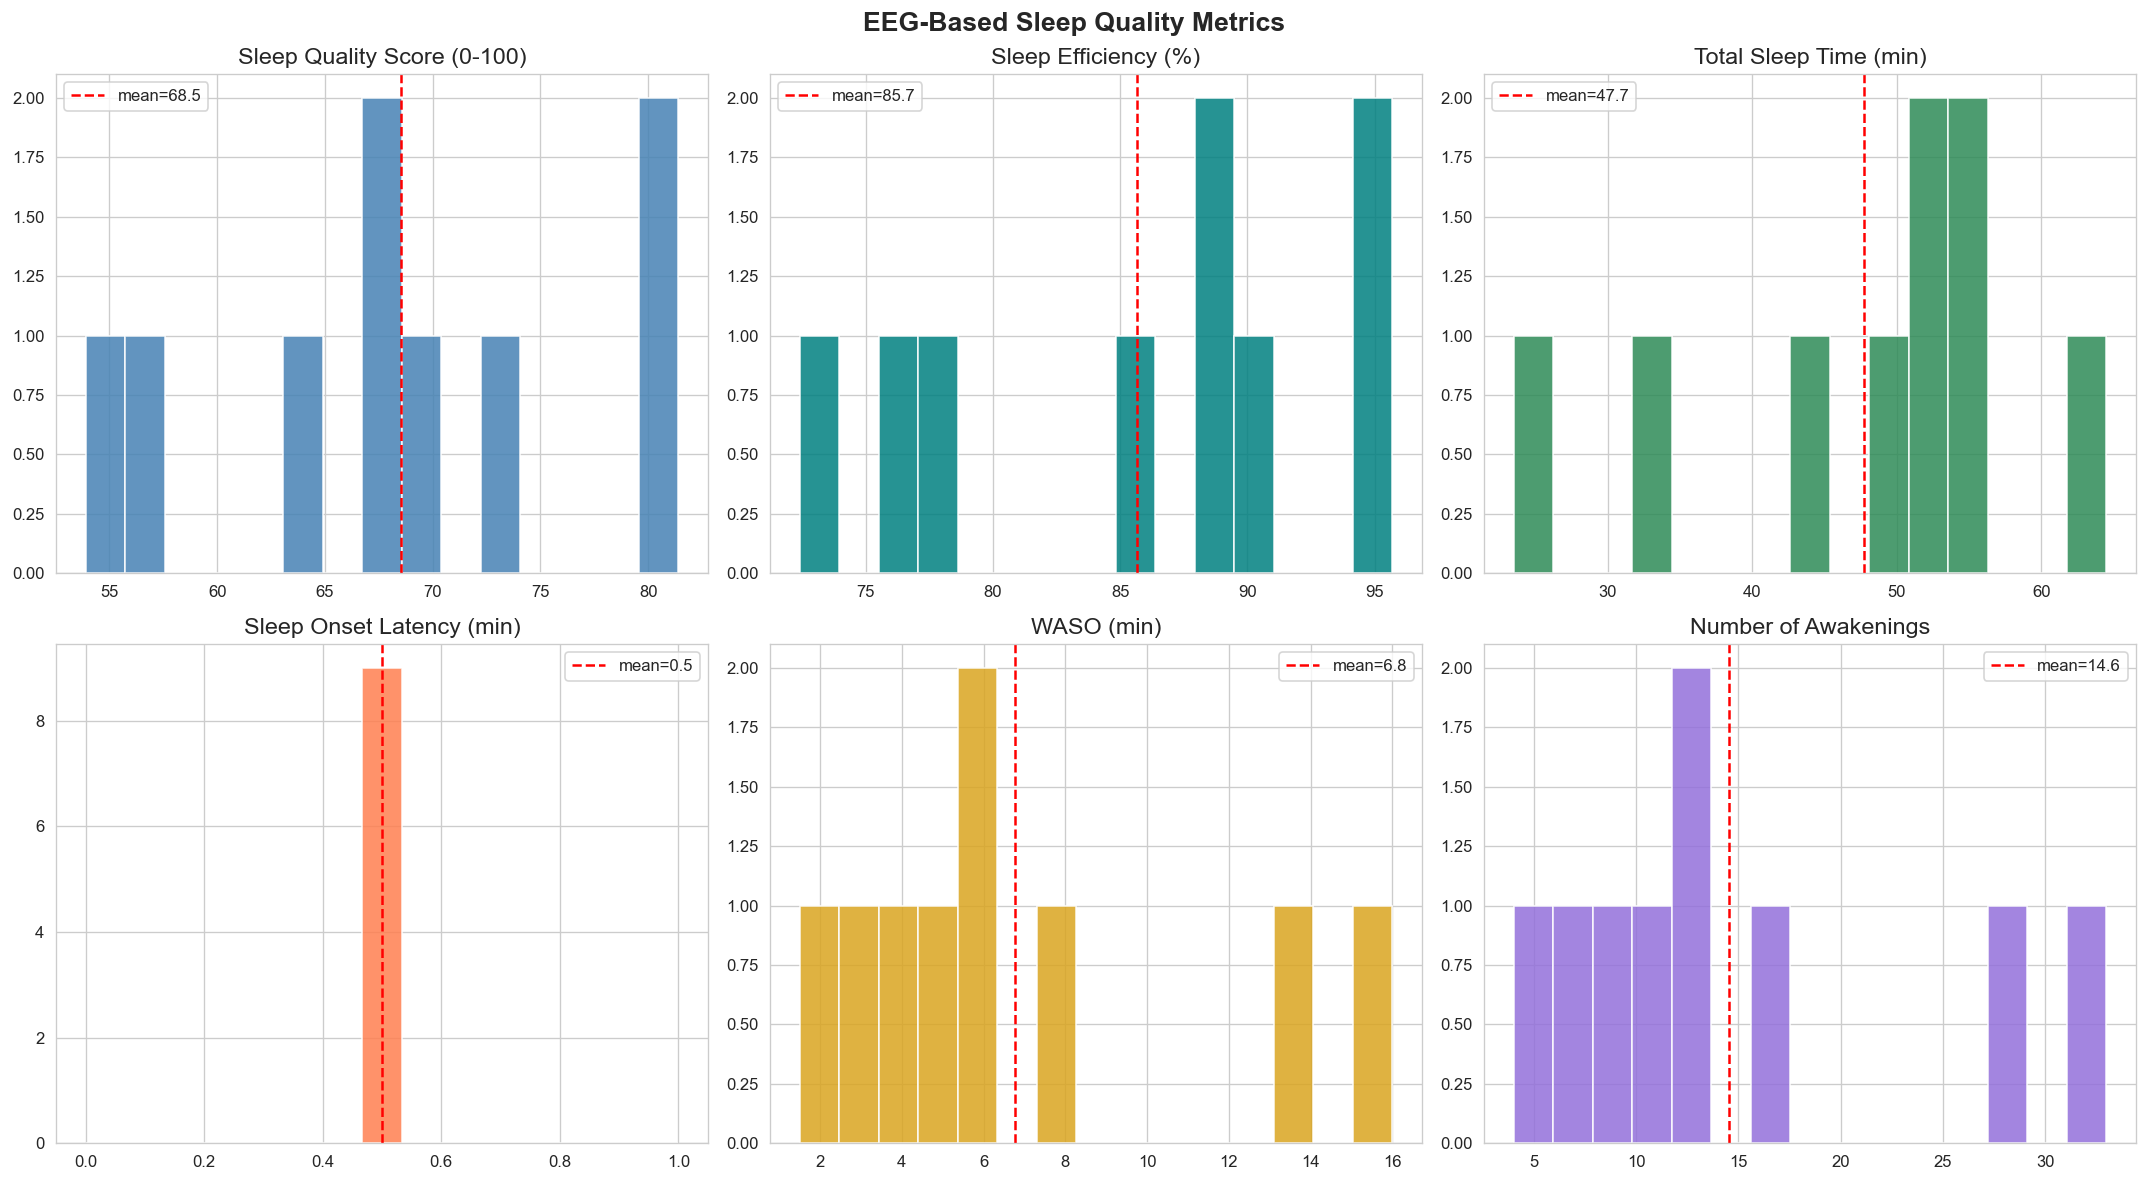

In [11]:
# ── EEG Sleep Quality Distribution ───────────────────────────
if eeg_available:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('EEG-Based Sleep Quality Metrics', fontsize=16, fontweight='bold')

    metrics = [
        ('sleep_quality_score', 'Sleep Quality Score (0-100)', 'steelblue'),
        ('efficiency_pct', 'Sleep Efficiency (%)', 'teal'),
        ('tst_min', 'Total Sleep Time (min)', 'seagreen'),
        ('sol_min', 'Sleep Onset Latency (min)', 'coral'),
        ('waso_min', 'WASO (min)', 'goldenrod'),
        ('awakenings', 'Number of Awakenings', 'mediumpurple'),
    ]

    for ax, (col, title, color) in zip(axes.flatten(), metrics):
        ax.hist(df_eeg[col], bins=15, color=color, edgecolor='white', alpha=0.85)
        ax.axvline(df_eeg[col].mean(), color='red', ls='--',
                   label=f'mean={df_eeg[col].mean():.1f}')
        ax.set_title(title)
        ax.legend()

    plt.tight_layout()
    plt.savefig('eeg_quality_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Skipped — EEG bridge not available.")

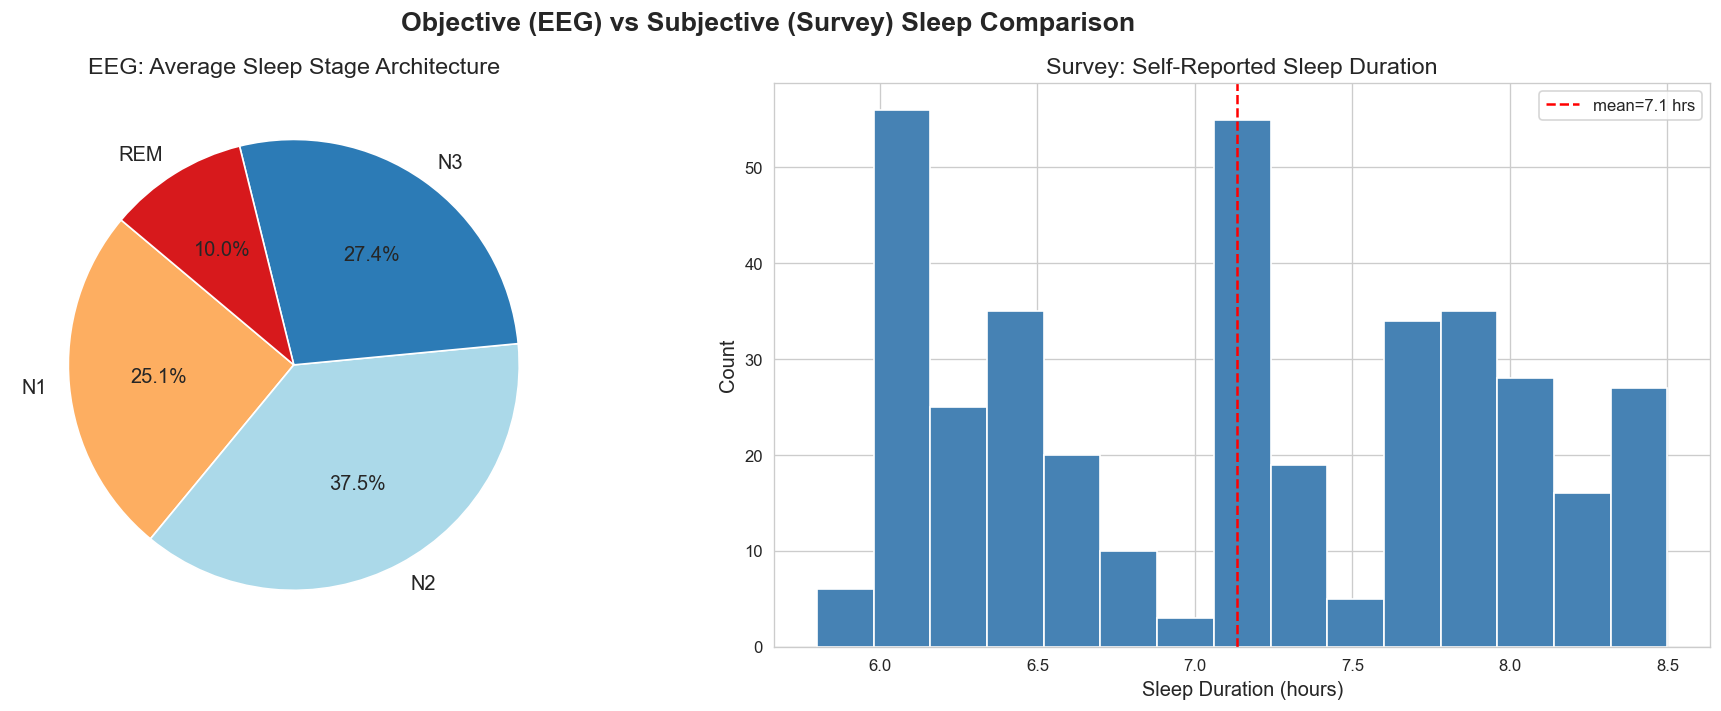


── EEG Objective Metrics ──
  Mean TST:            47.7 min (0.8 hrs)
  Mean Efficiency:     85.7%
  Mean Quality Score:  68.5/100
  Mean SOL:            0.5 min
  Mean WASO:           6.8 min

── Survey Subjective Metrics ──
  Mean Self-Reported Duration: 7.1 hrs
  Mean Self-Reported Quality:  7.3/10


In [12]:
# ── Sleep Architecture Comparison (EEG vs Survey) ────────────
if eeg_available:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # EEG stage breakdown
    stage_cols = ['pct_N1', 'pct_N2', 'pct_N3', 'pct_REM']
    stage_means = df_eeg[stage_cols].mean()
    colors_eeg = ['#fdae61', '#abd9e9', '#2c7bb6', '#d7191c']
    axes[0].pie(stage_means, labels=['N1', 'N2', 'N3', 'REM'], autopct='%1.1f%%',
                colors=colors_eeg, startangle=140, textprops={'fontsize': 12})
    axes[0].set_title('EEG: Average Sleep Stage Architecture', fontsize=14)

    # Survey: Sleep Duration distribution
    if 'Sleep Duration' in df.columns:
        axes[1].hist(df['Sleep Duration'], bins=15, color='steelblue', edgecolor='white')
        axes[1].axvline(df['Sleep Duration'].mean(), color='red', ls='--',
                        label=f"mean={df['Sleep Duration'].mean():.1f} hrs")
        axes[1].set_xlabel('Sleep Duration (hours)')
        axes[1].set_ylabel('Count')
        axes[1].set_title('Survey: Self-Reported Sleep Duration', fontsize=14)
        axes[1].legend()
    else:
        axes[1].text(0.5, 0.5, 'Sleep Duration\nnot in survey data',
                     ha='center', va='center', fontsize=14)
        axes[1].set_title('Survey Data')

    plt.suptitle('Objective (EEG) vs Subjective (Survey) Sleep Comparison',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('eeg_vs_survey_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Numeric comparison table
    print("\n── EEG Objective Metrics ──")
    print(f"  Mean TST:            {df_eeg['tst_min'].mean():.1f} min ({df_eeg['tst_min'].mean()/60:.1f} hrs)")
    print(f"  Mean Efficiency:     {df_eeg['efficiency_pct'].mean():.1f}%")
    print(f"  Mean Quality Score:  {df_eeg['sleep_quality_score'].mean():.1f}/100")
    print(f"  Mean SOL:            {df_eeg['sol_min'].mean():.1f} min")
    print(f"  Mean WASO:           {df_eeg['waso_min'].mean():.1f} min")

    if 'Sleep Duration' in df.columns:
        print(f"\n── Survey Subjective Metrics ──")
        print(f"  Mean Self-Reported Duration: {df['Sleep Duration'].mean():.1f} hrs")
        if 'Quality of Sleep' in df.columns:
            print(f"  Mean Self-Reported Quality:  {df['Quality of Sleep'].mean():.1f}/10")
else:
    print("Skipped — EEG bridge not available.")

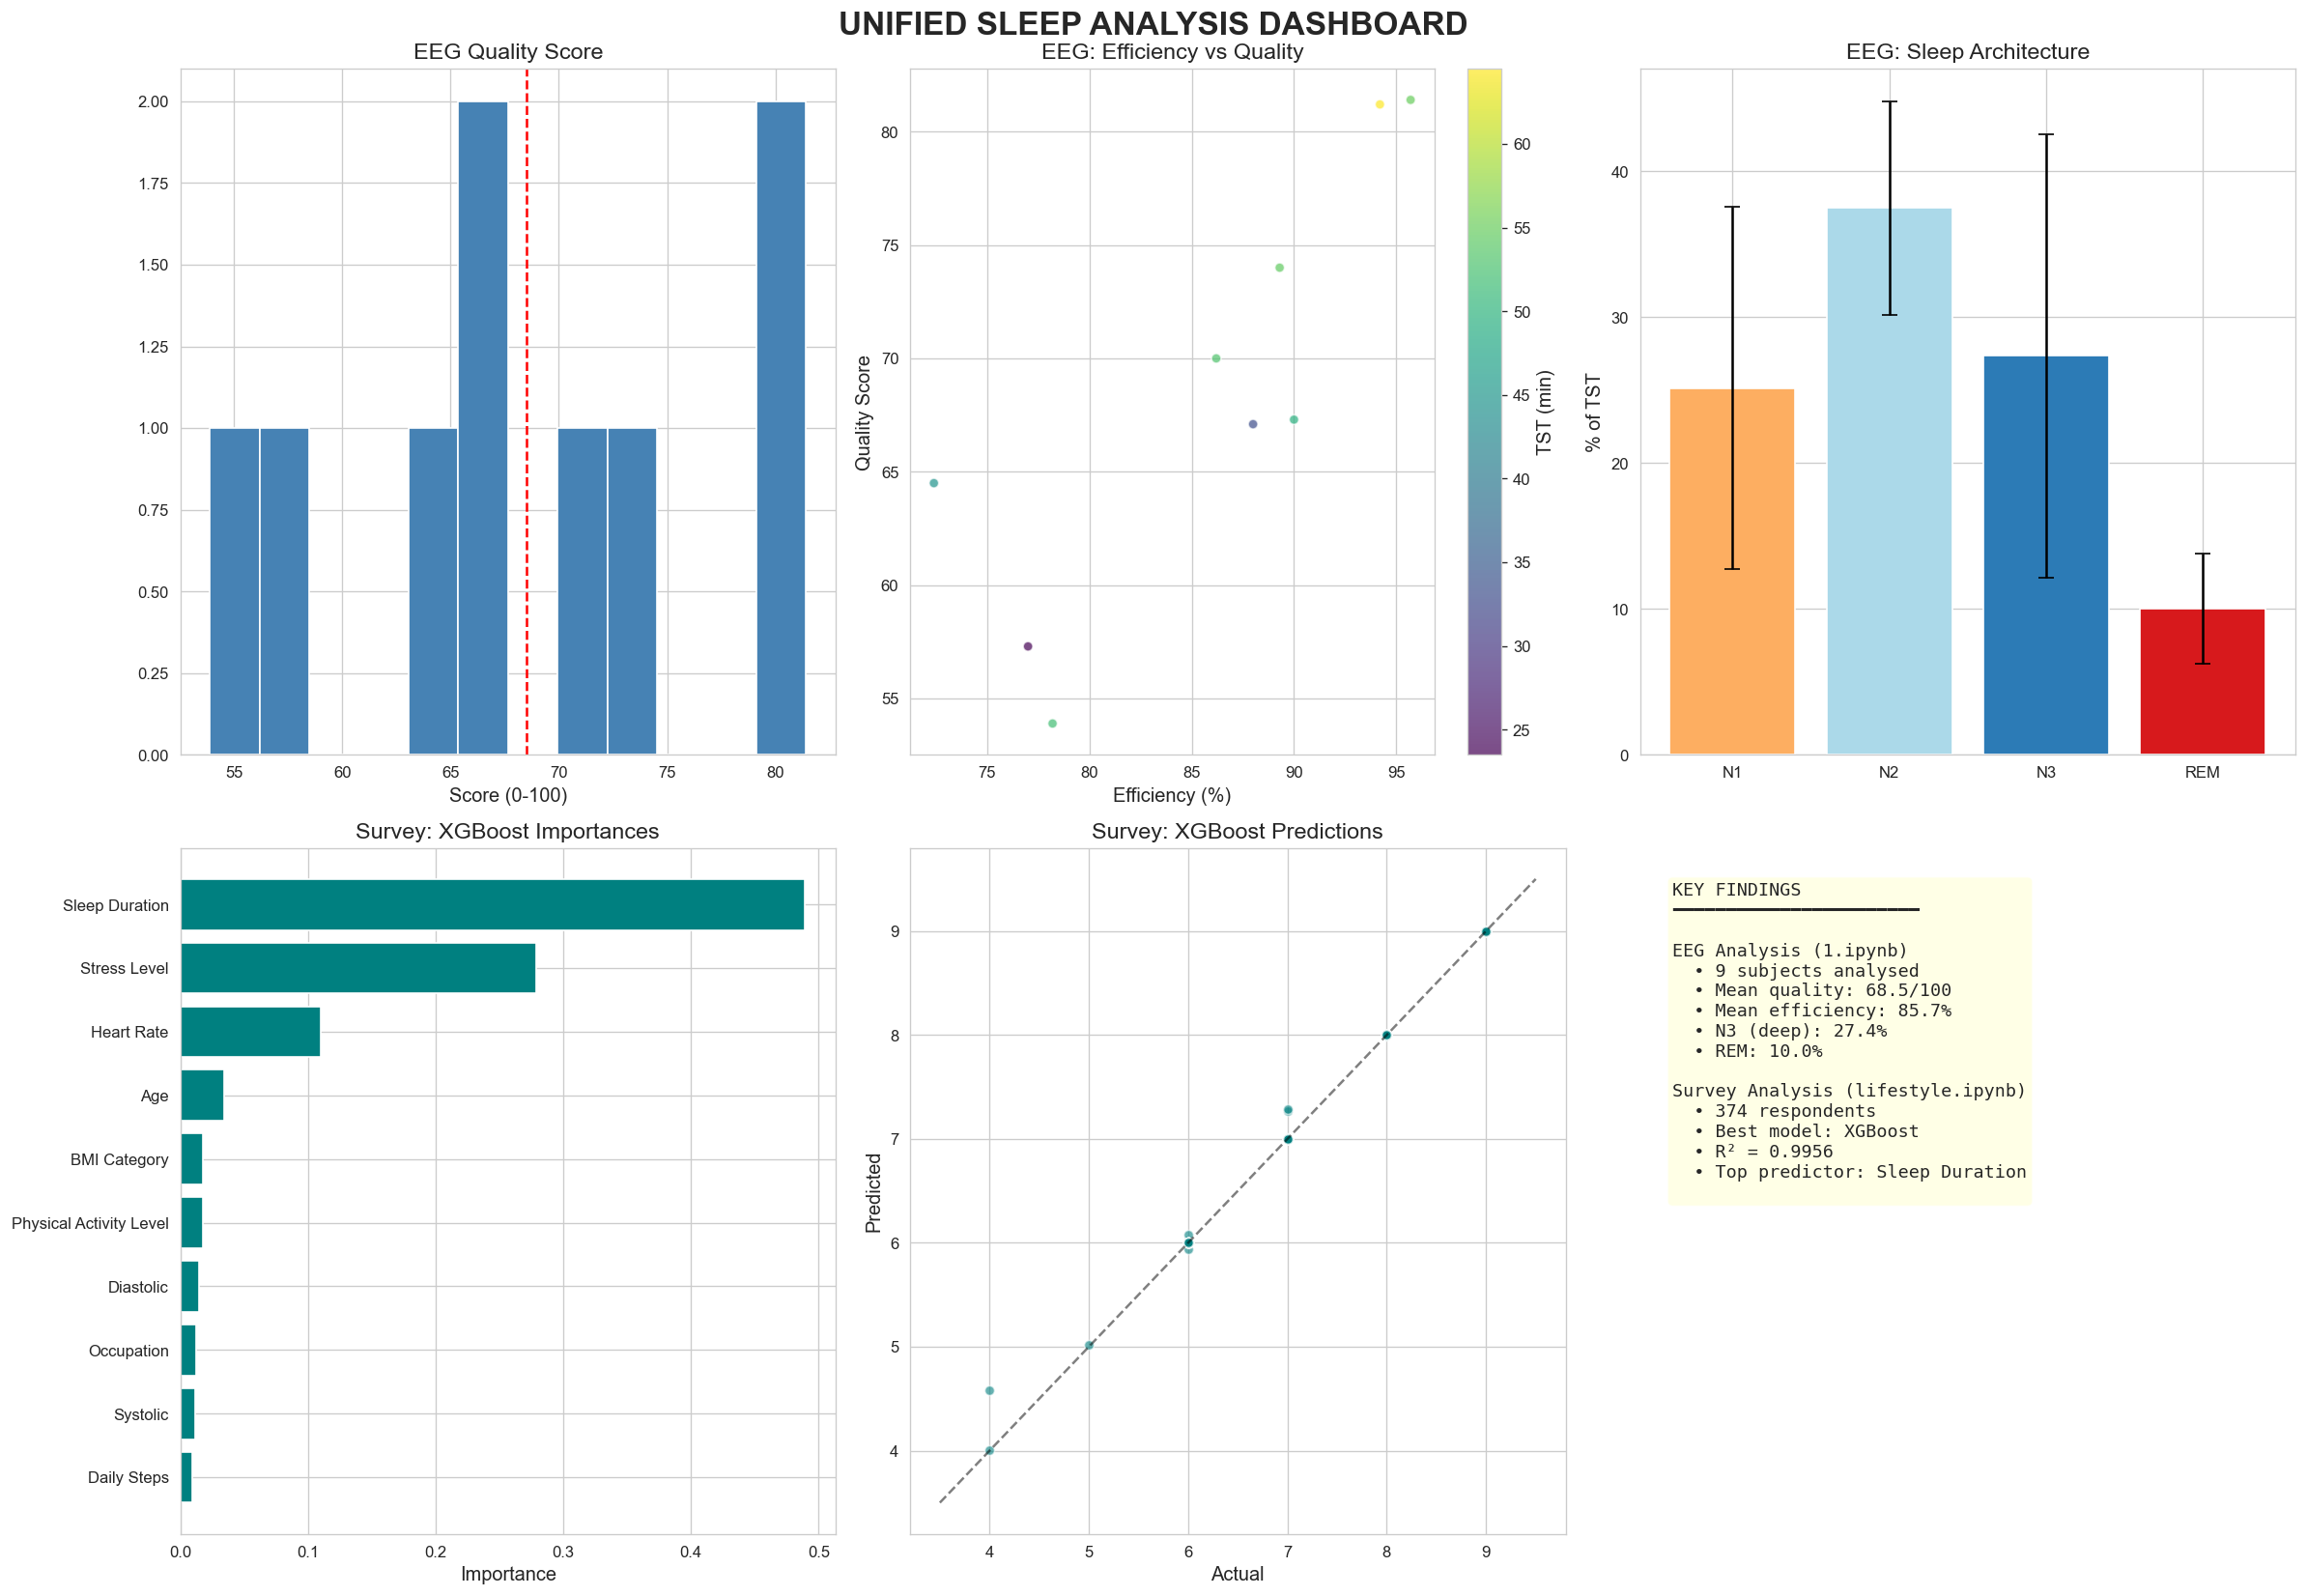

✅ unified_dashboard.png saved


In [13]:
# ── Unified Findings Dashboard ───────────────────────────────
if eeg_available:
    fig = plt.figure(figsize=(20, 14))
    fig.suptitle('UNIFIED SLEEP ANALYSIS DASHBOARD', fontsize=20, fontweight='bold', y=0.98)

    # 1. EEG Quality Score histogram
    ax1 = fig.add_subplot(2, 3, 1)
    ax1.hist(df_eeg['sleep_quality_score'], bins=12, color='steelblue', edgecolor='white')
    ax1.axvline(df_eeg['sleep_quality_score'].mean(), color='red', ls='--')
    ax1.set_title('EEG Quality Score')
    ax1.set_xlabel('Score (0-100)')

    # 2. EEG Efficiency vs Quality scatter
    ax2 = fig.add_subplot(2, 3, 2)
    sc = ax2.scatter(df_eeg['efficiency_pct'], df_eeg['sleep_quality_score'],
                     c=df_eeg['tst_min'], cmap='viridis', alpha=0.7, edgecolor='white')
    plt.colorbar(sc, ax=ax2, label='TST (min)')
    ax2.set_xlabel('Efficiency (%)')
    ax2.set_ylabel('Quality Score')
    ax2.set_title('EEG: Efficiency vs Quality')

    # 3. EEG Stage architecture (bar)
    ax3 = fig.add_subplot(2, 3, 3)
    stage_cols = ['pct_N1', 'pct_N2', 'pct_N3', 'pct_REM']
    means = df_eeg[stage_cols].mean()
    stds = df_eeg[stage_cols].std()
    colors_stages = ['#fdae61', '#abd9e9', '#2c7bb6', '#d7191c']
    ax3.bar(['N1', 'N2', 'N3', 'REM'], means, yerr=stds, color=colors_stages,
            edgecolor='white', capsize=5)
    ax3.set_ylabel('% of TST')
    ax3.set_title('EEG: Sleep Architecture')

    # 4. Survey feature importance (best model)
    ax4 = fig.add_subplot(2, 3, 4)
    best_name = comp['r2'].idxmax()
    best_imp = models[best_name]['model'].feature_importances_
    top_idx = np.argsort(best_imp)[-10:]
    ax4.barh(np.array(feature_cols)[top_idx], best_imp[top_idx], color='teal')
    ax4.set_xlabel('Importance')
    ax4.set_title(f'Survey: {best_name} Importances')

    # 5. Survey predictions scatter (best model)
    ax5 = fig.add_subplot(2, 3, 5)
    best_pred = models[best_name]['pred']
    ax5.scatter(y_test, best_pred, alpha=0.6, color='teal', edgecolor='white')
    lims = [min(y_test.min(), best_pred.min()) - 0.5,
            max(y_test.max(), best_pred.max()) + 0.5]
    ax5.plot(lims, lims, '--k', alpha=0.5)
    ax5.set_xlabel('Actual')
    ax5.set_ylabel('Predicted')
    ax5.set_title(f'Survey: {best_name} Predictions')

    # 6. Key findings text box
    ax6 = fig.add_subplot(2, 3, 6)
    ax6.axis('off')
    findings = (
        f"KEY FINDINGS\n"
        f"━━━━━━━━━━━━━━━━━━━━━━━\n\n"
        f"EEG Analysis (1.ipynb)\n"
        f"  • {df_eeg.shape[0]} subjects analysed\n"
        f"  • Mean quality: {df_eeg['sleep_quality_score'].mean():.1f}/100\n"
        f"  • Mean efficiency: {df_eeg['efficiency_pct'].mean():.1f}%\n"
        f"  • N3 (deep): {df_eeg['pct_N3'].mean():.1f}%\n"
        f"  • REM: {df_eeg['pct_REM'].mean():.1f}%\n\n"
        f"Survey Analysis (lifestyle.ipynb)\n"
        f"  • {df.shape[0]} respondents\n"
        f"  • Best model: {best_name}\n"
        f"  • R² = {comp.loc[best_name, 'r2']:.4f}\n"
        f"  • Top predictor: {feature_cols[np.argmax(best_imp)]}\n"
    )
    ax6.text(0.05, 0.95, findings, transform=ax6.transAxes, fontsize=11,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.savefig('unified_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ unified_dashboard.png saved")
else:
    print("Skipped — EEG bridge not available. Run 1.ipynb first.")

In [14]:
# ── Save All Outputs ─────────────────────────────────────────
print("=" * 60)
print("LIFESTYLE ANALYSIS — FINAL SUMMARY")
print("=" * 60)

# Model comparison
comp.to_csv('lifestyle_model_results.csv')
print("✅ lifestyle_model_results.csv")

# Check all saved files
output_files = [
    'lifestyle_correlation.png',
    'lifestyle_feature_importance.png',
    'lifestyle_pred_vs_actual.png',
    'lifestyle_model_results.csv',
]
if eeg_available:
    output_files += [
        'eeg_quality_distributions.png',
        'eeg_vs_survey_comparison.png',
        'unified_dashboard.png',
    ]

for f in output_files:
    if os.path.exists(f):
        size_kb = os.path.getsize(f) / 1024
        print(f"  ✅ {f} ({size_kb:.0f} KB)")
    else:
        print(f"  ⏳ {f} (will be created on run)")

print(f"\n{'=' * 60}")
print("DONE — Both pipelines complete.")
print("  1.ipynb  → EEG staging (6 models) + eeg_sleep_quality.csv")
print("  lifestyle.ipynb → Survey analysis (RF + XGBoost) + bridge comparison")
print(f"{'=' * 60}")

LIFESTYLE ANALYSIS — FINAL SUMMARY
✅ lifestyle_model_results.csv
  ✅ lifestyle_correlation.png (123 KB)
  ✅ lifestyle_feature_importance.png (98 KB)
  ✅ lifestyle_pred_vs_actual.png (91 KB)
  ✅ lifestyle_model_results.csv (0 KB)
  ✅ eeg_quality_distributions.png (134 KB)
  ✅ eeg_vs_survey_comparison.png (106 KB)
  ✅ unified_dashboard.png (262 KB)

DONE — Both pipelines complete.
  1.ipynb  → EEG staging (6 models) + eeg_sleep_quality.csv
  lifestyle.ipynb → Survey analysis (RF + XGBoost) + bridge comparison
